MST ótima (Kruskal) = 52



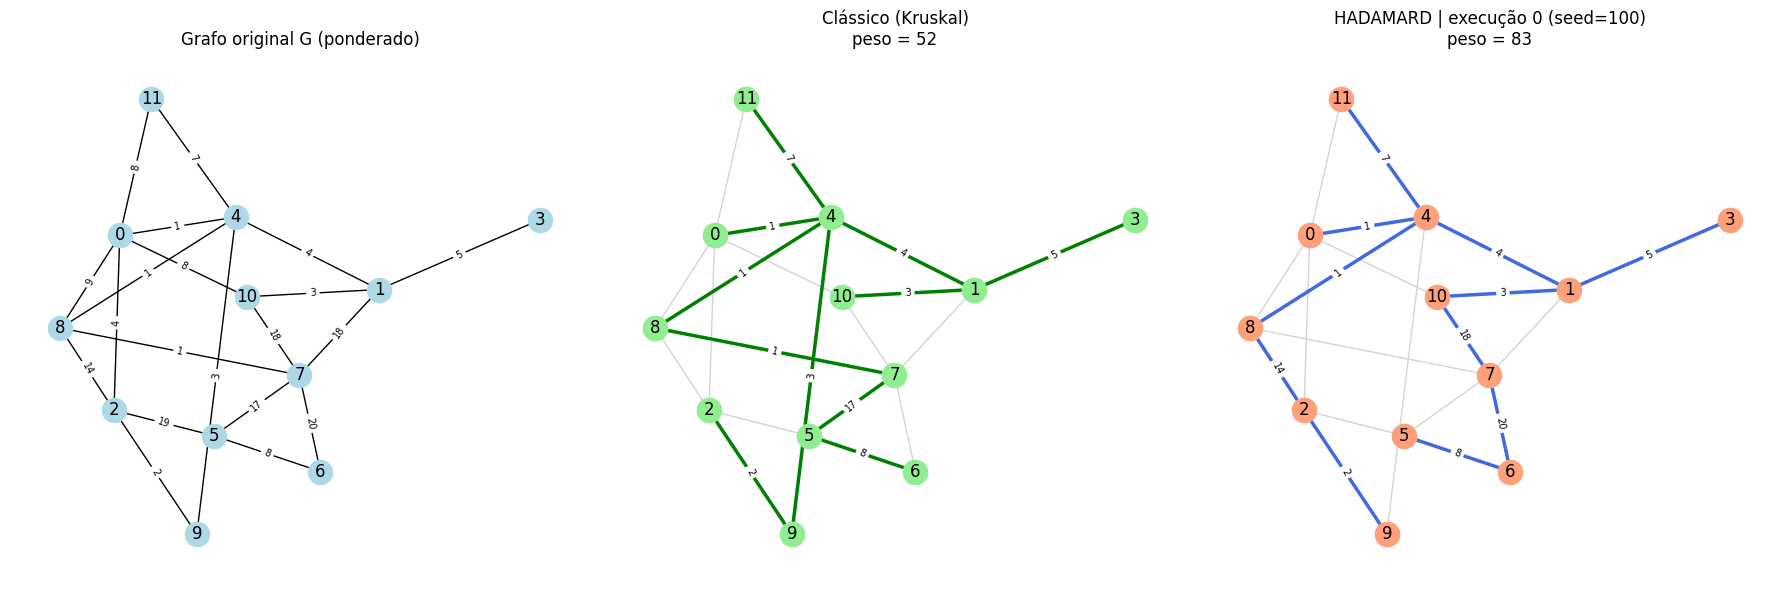

[hadamard     ] execução 0 (seed=100) -> peso = 83


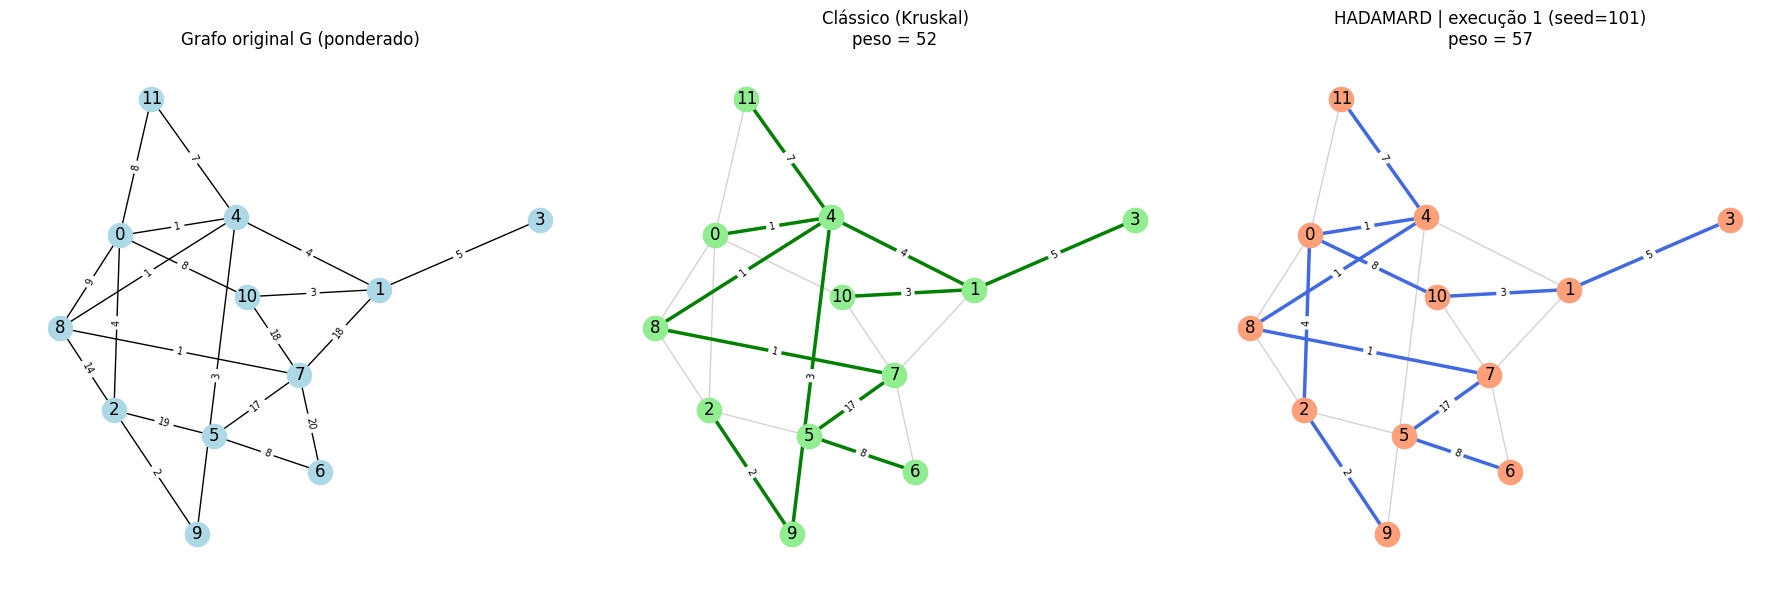

[hadamard     ] execução 1 (seed=101) -> peso = 57


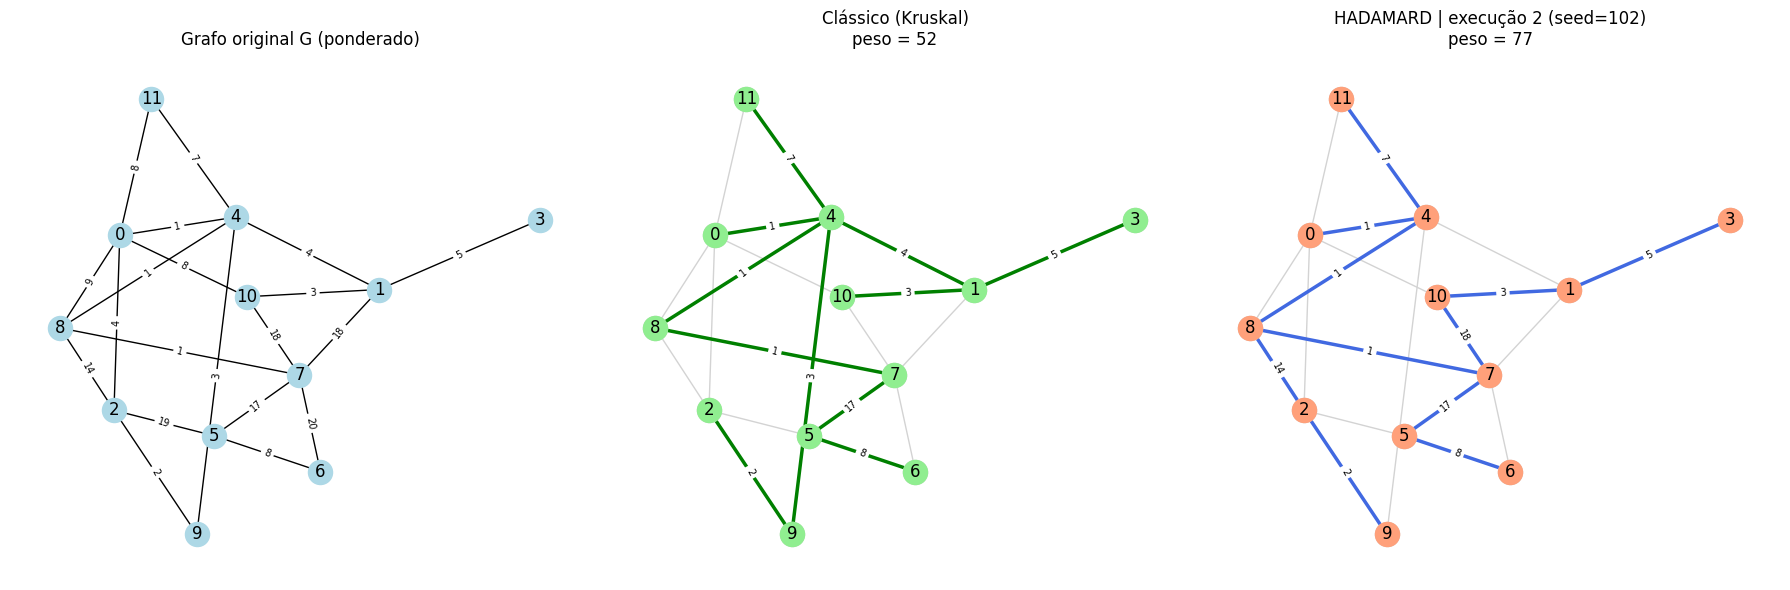

[hadamard     ] execução 2 (seed=102) -> peso = 77


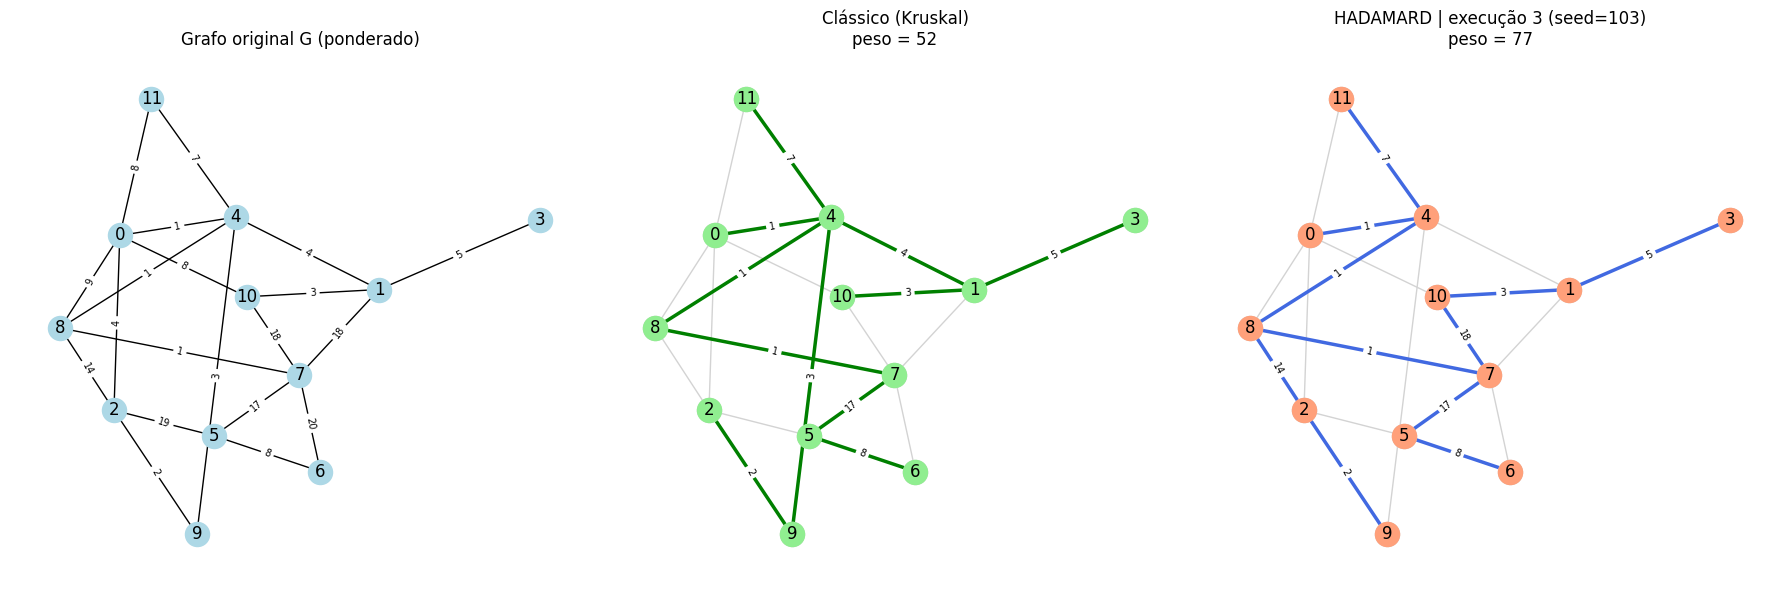

[hadamard     ] execução 3 (seed=103) -> peso = 77
  -> média = 73.5 | melhor = 57



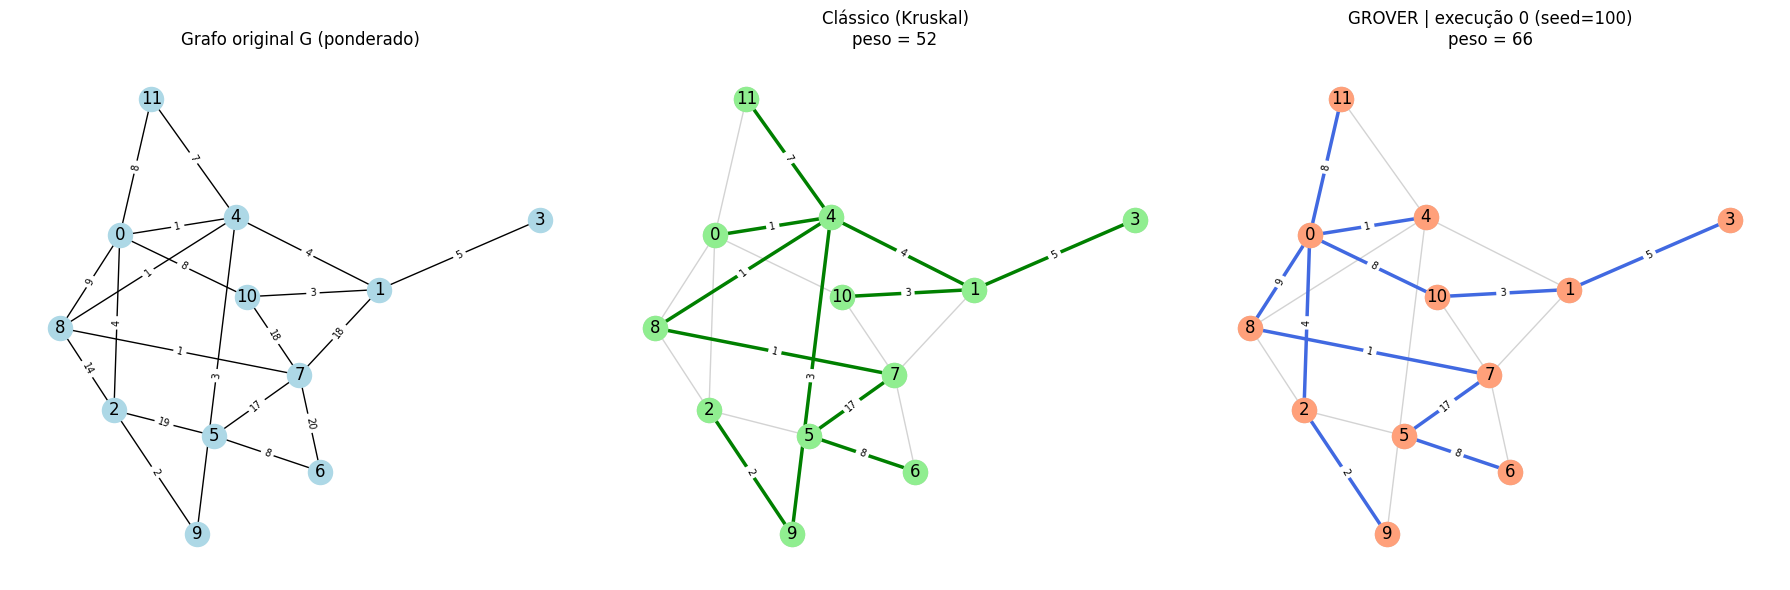

[grover       ] execução 0 (seed=100) -> peso = 66


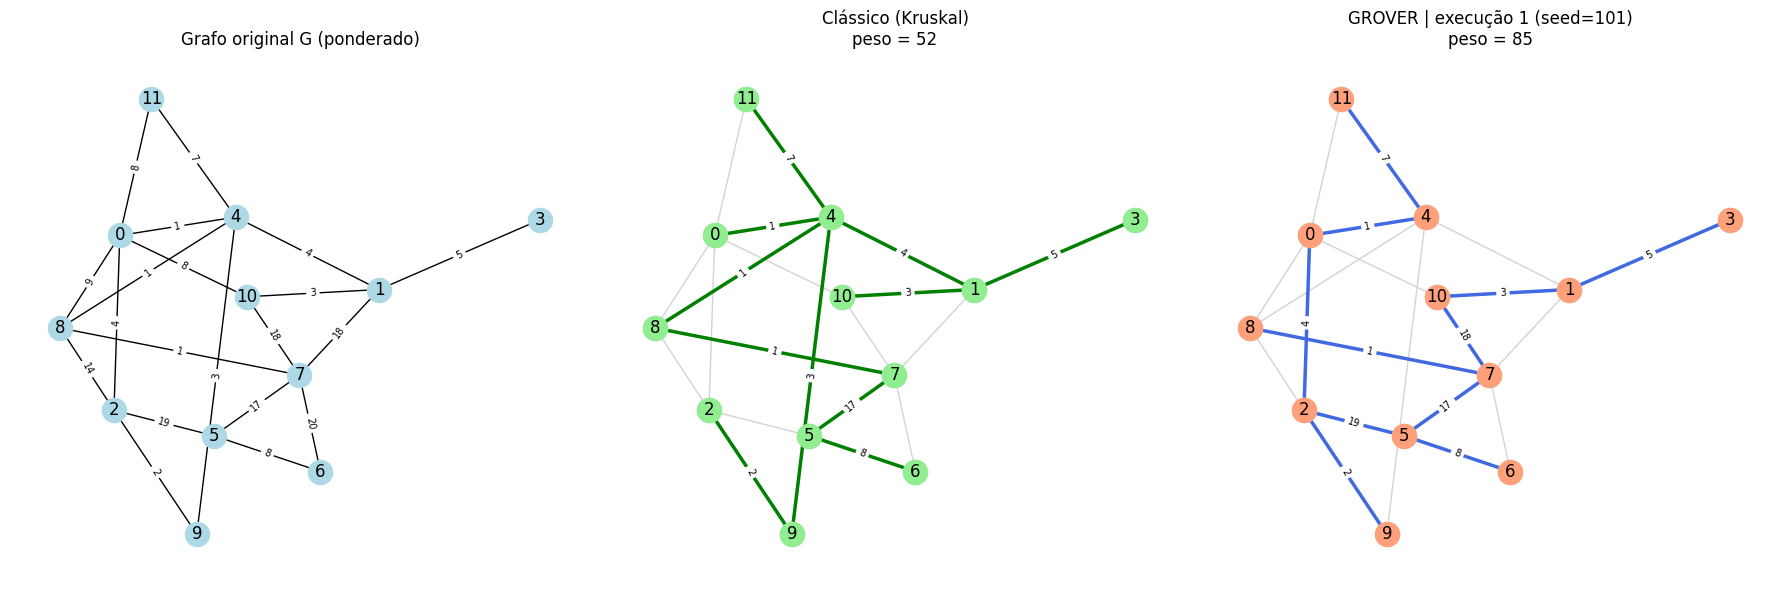

[grover       ] execução 1 (seed=101) -> peso = 85


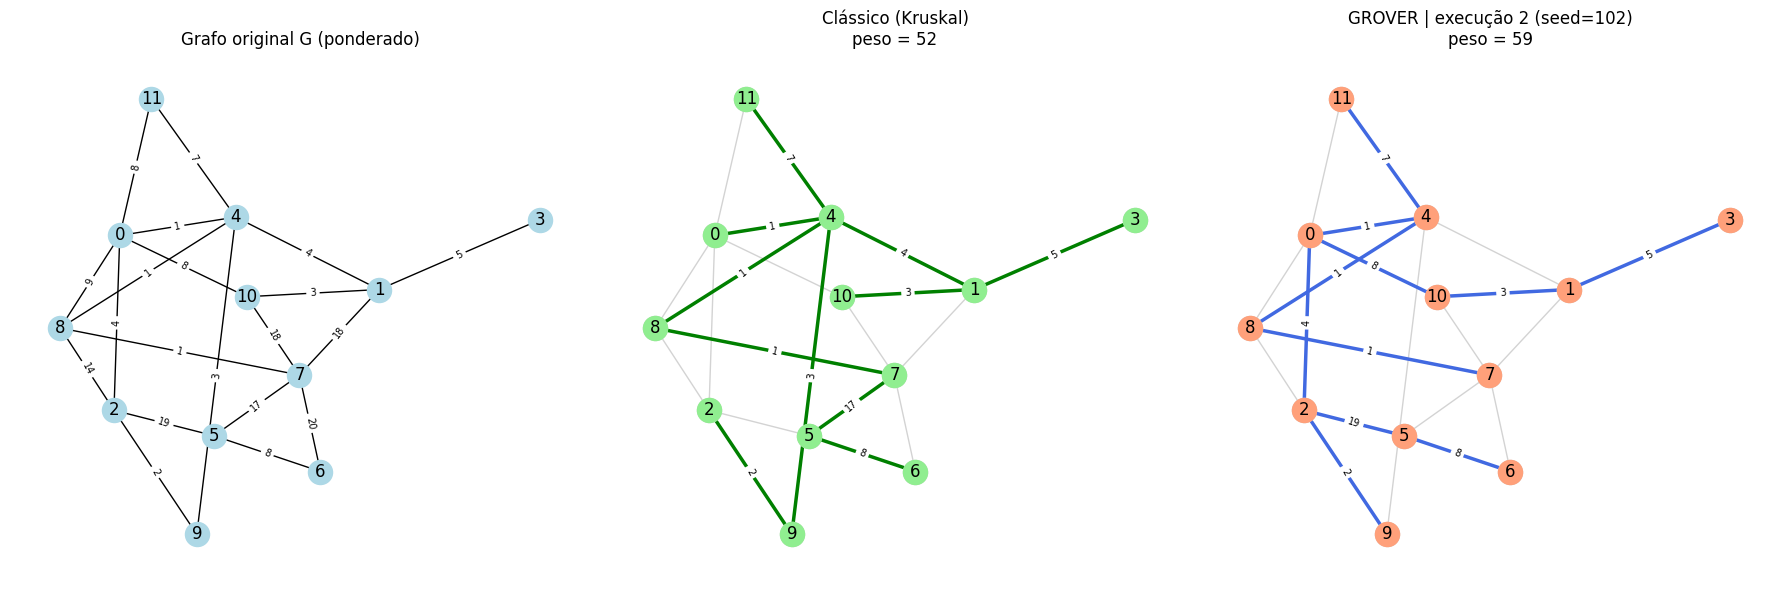

[grover       ] execução 2 (seed=102) -> peso = 59


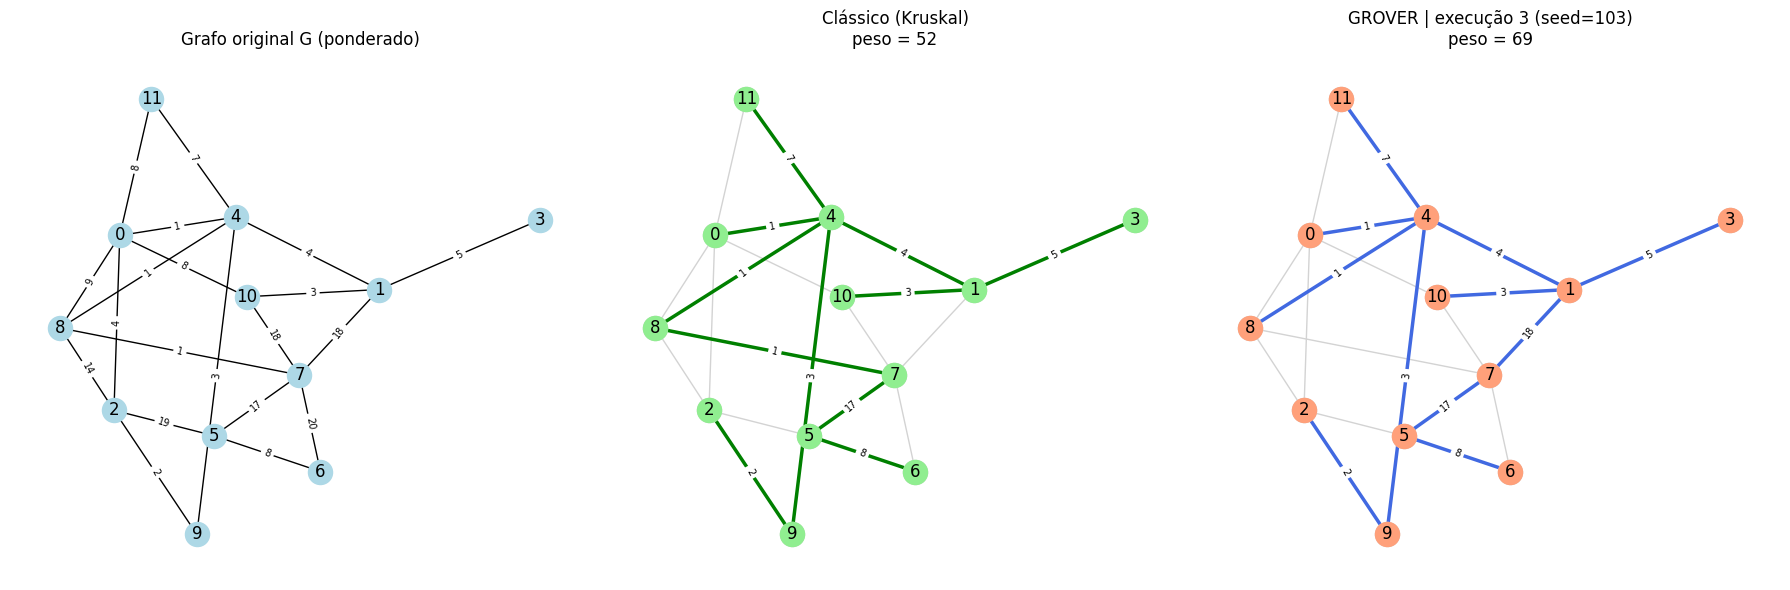

[grover       ] execução 3 (seed=103) -> peso = 69
  -> média = 69.8 | melhor = 59



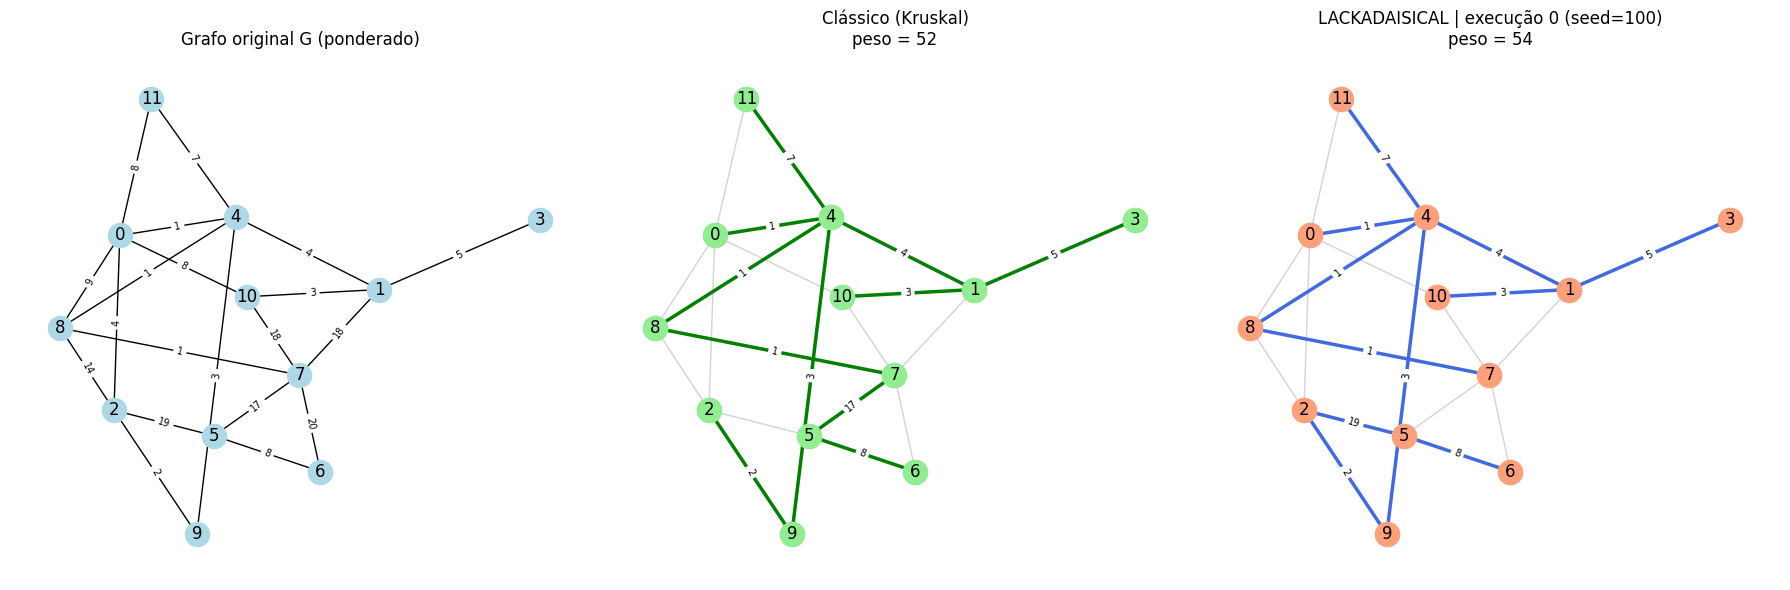

[lackadaisical] execução 0 (seed=100) -> peso = 54


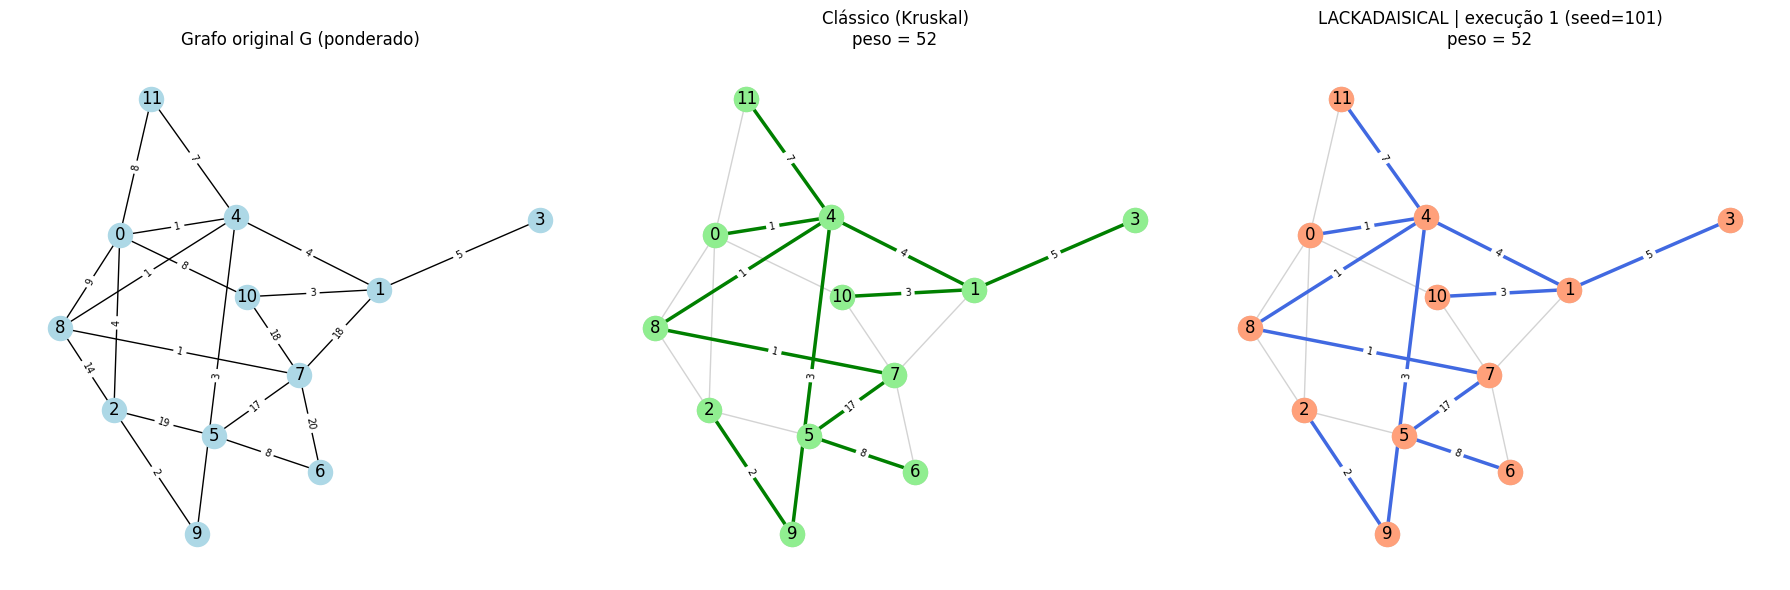

[lackadaisical] execução 1 (seed=101) -> peso = 52


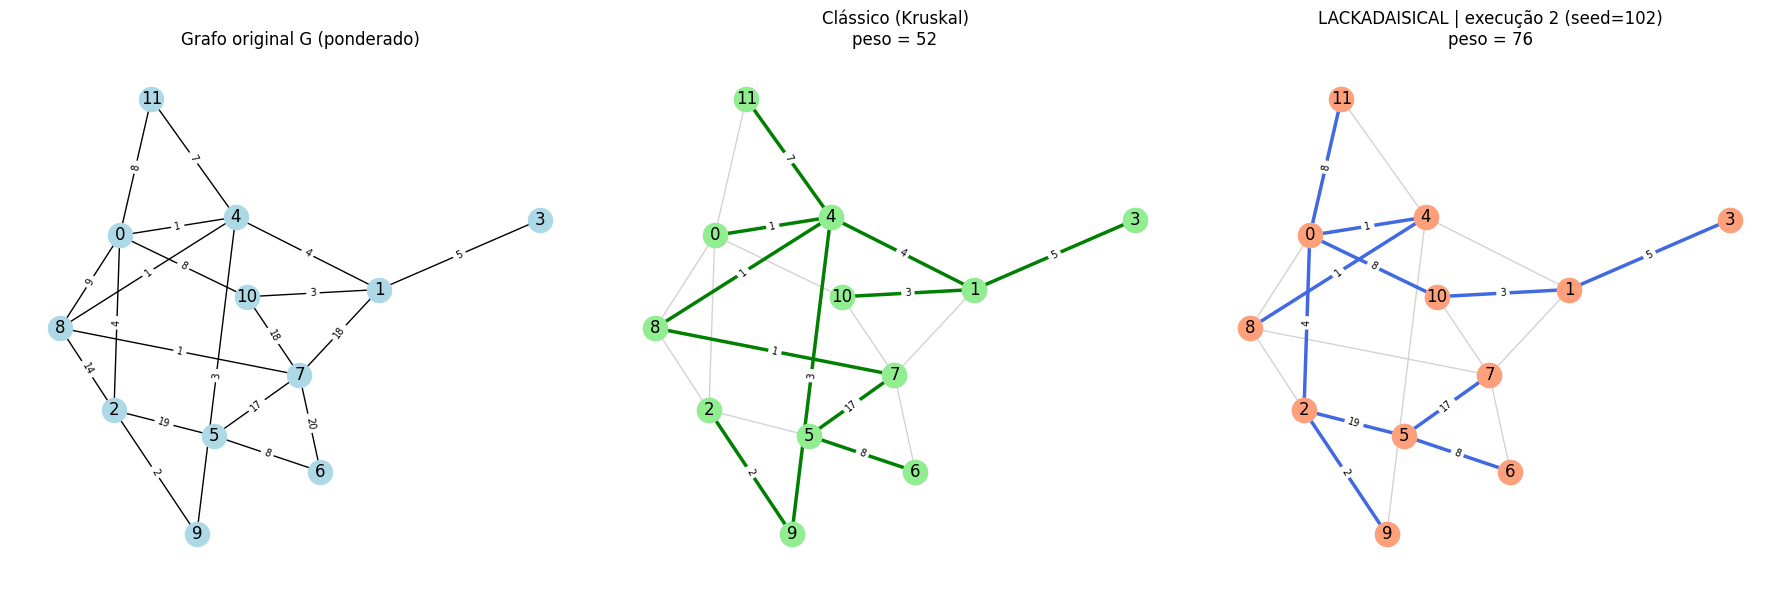

[lackadaisical] execução 2 (seed=102) -> peso = 76


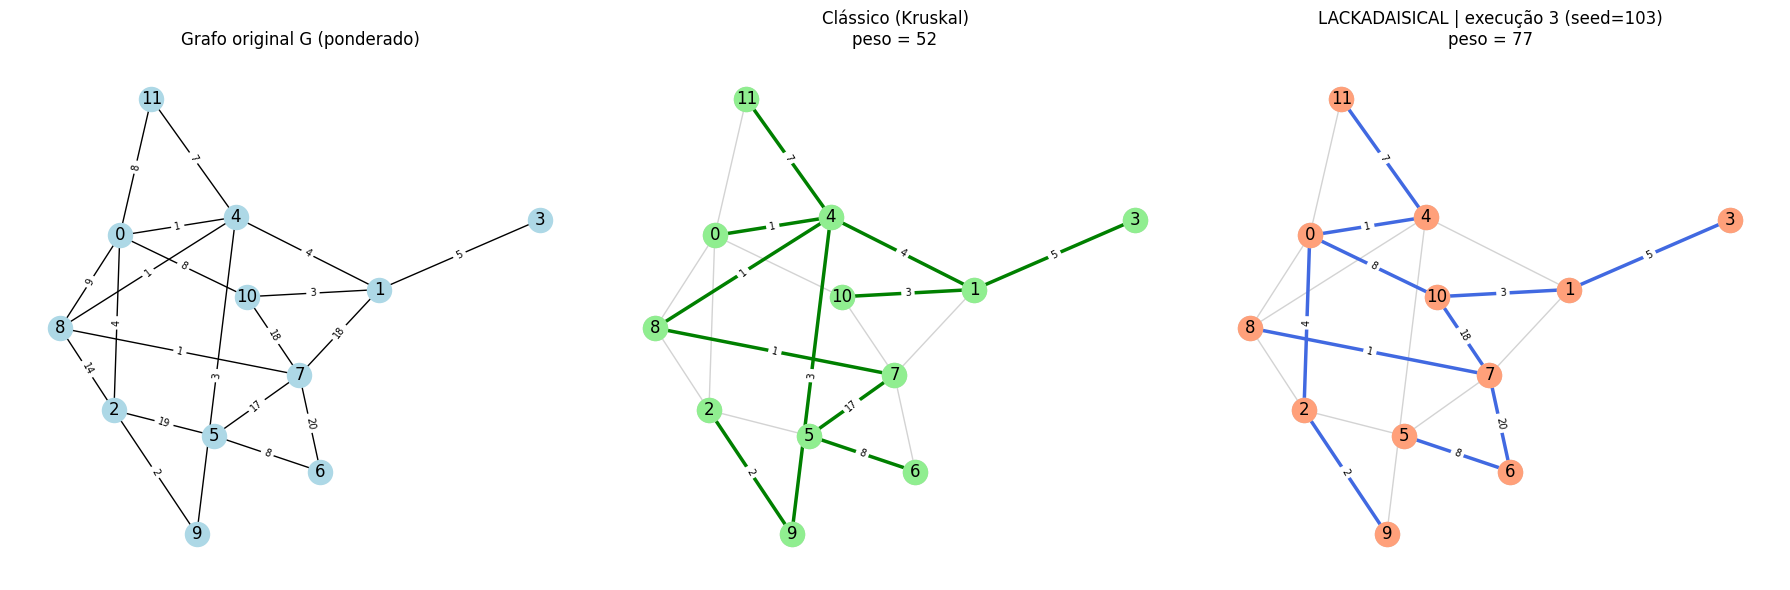

[lackadaisical] execução 3 (seed=103) -> peso = 77
  -> média = 64.8 | melhor = 52



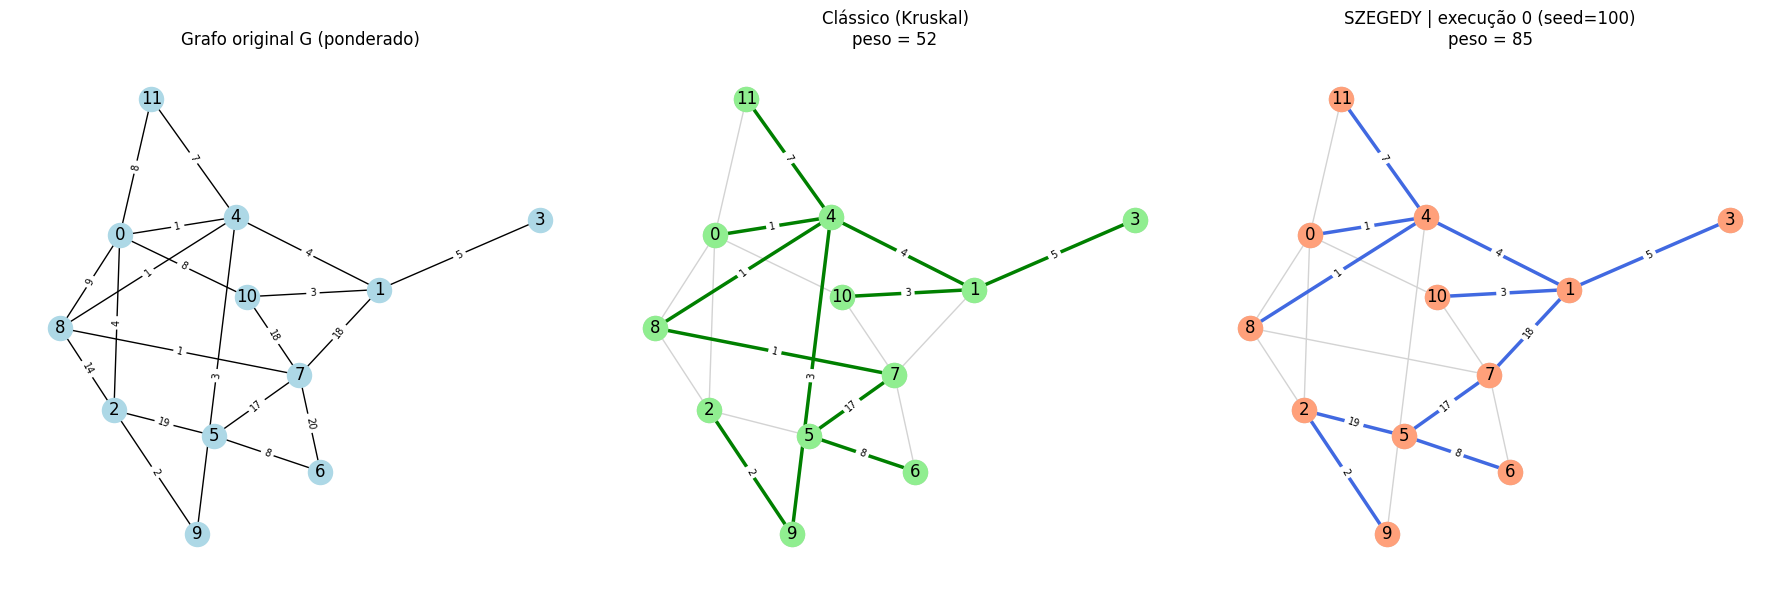

[szegedy      ] execução 0 (seed=100) -> peso = 85


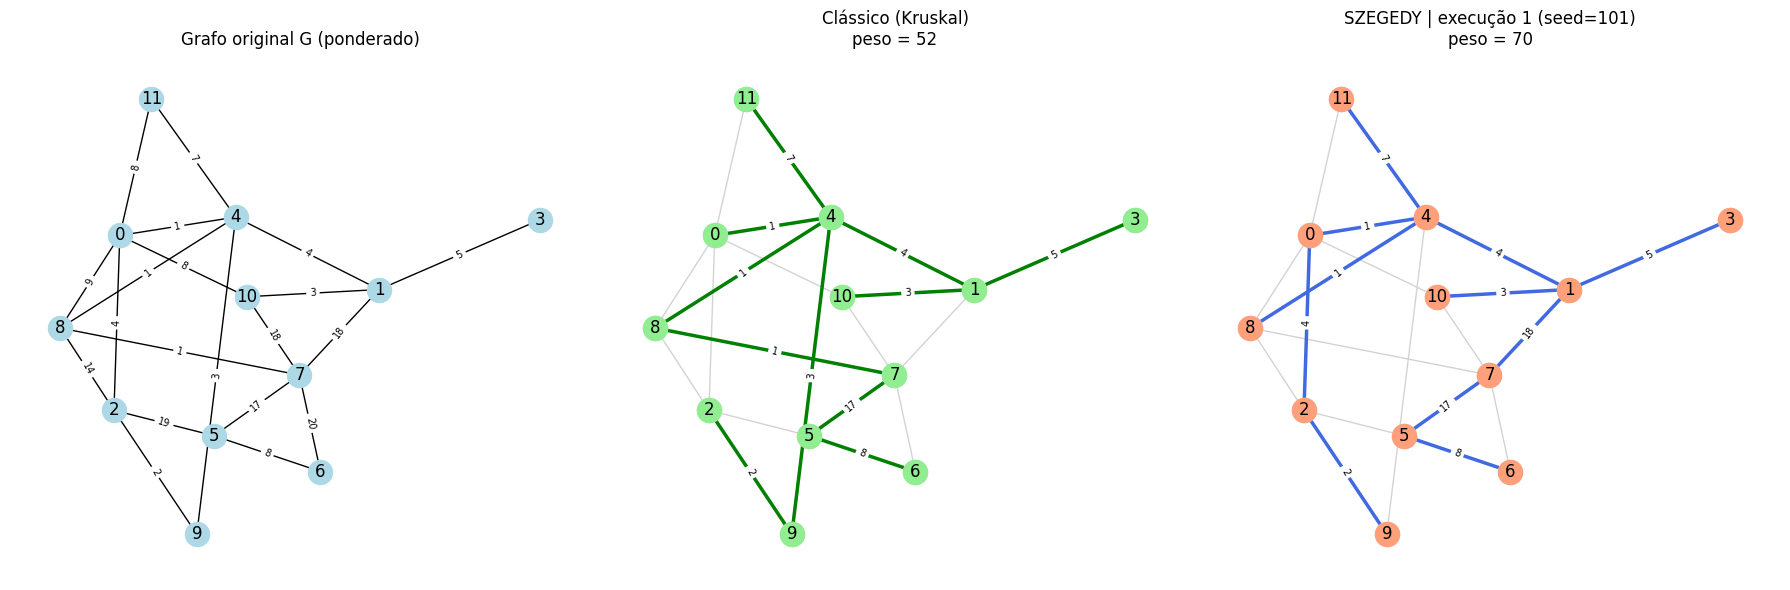

[szegedy      ] execução 1 (seed=101) -> peso = 70


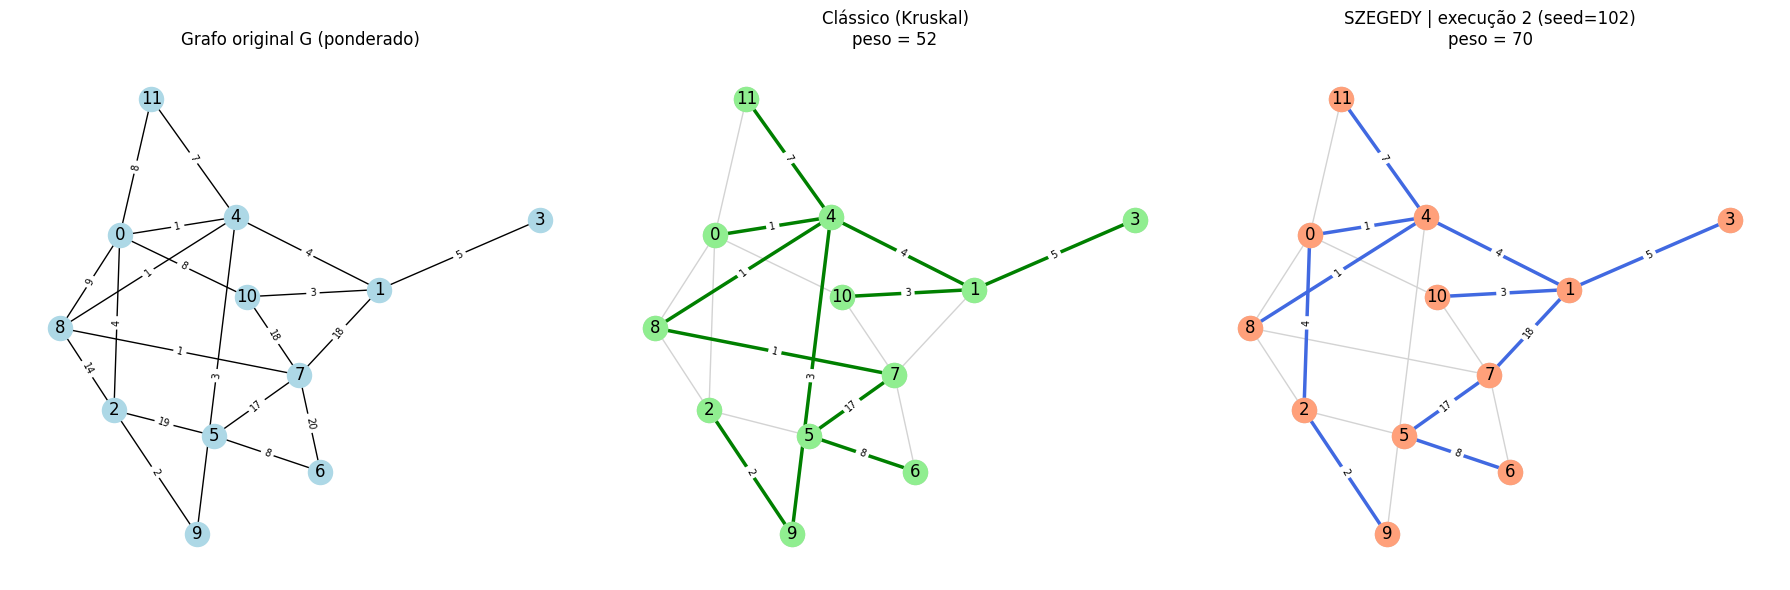

[szegedy      ] execução 2 (seed=102) -> peso = 70


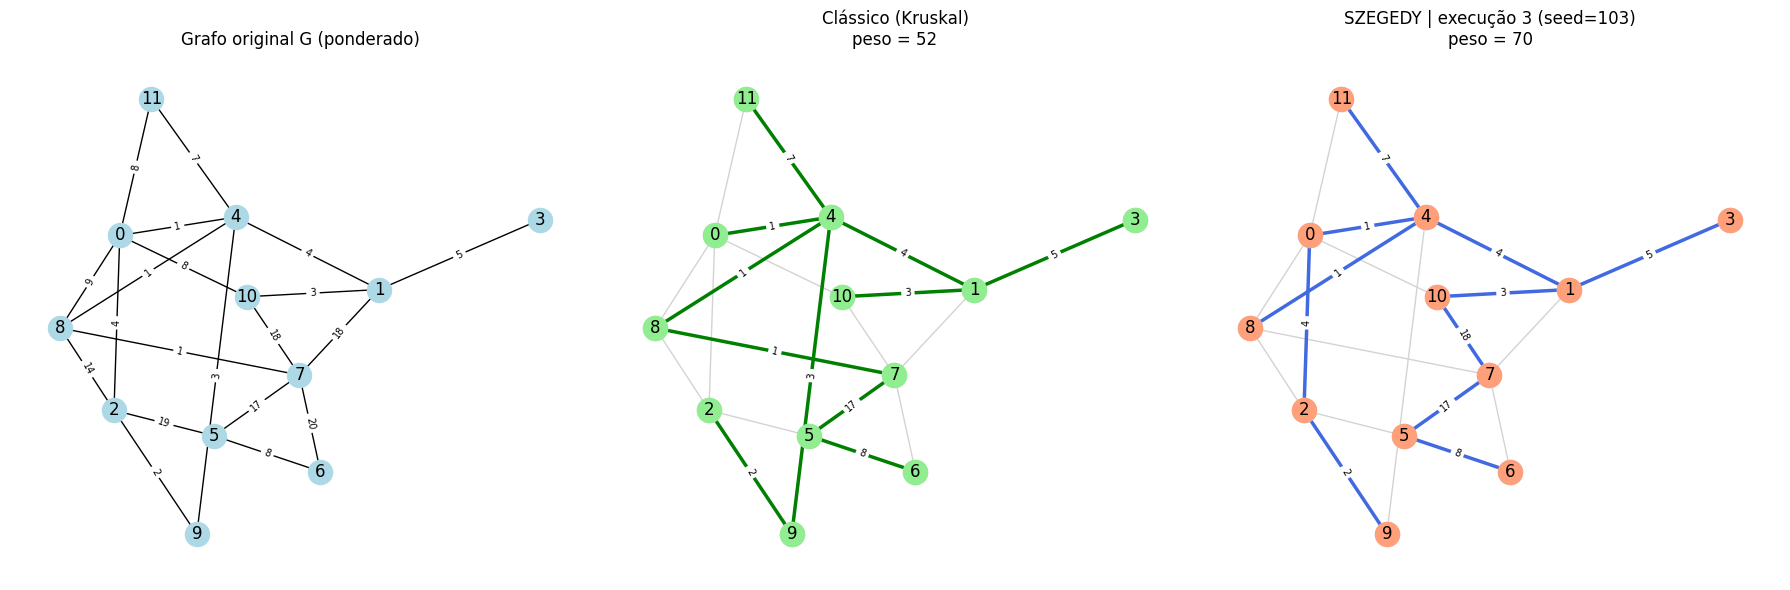

[szegedy      ] execução 3 (seed=103) -> peso = 70
  -> média = 73.8 | melhor = 70



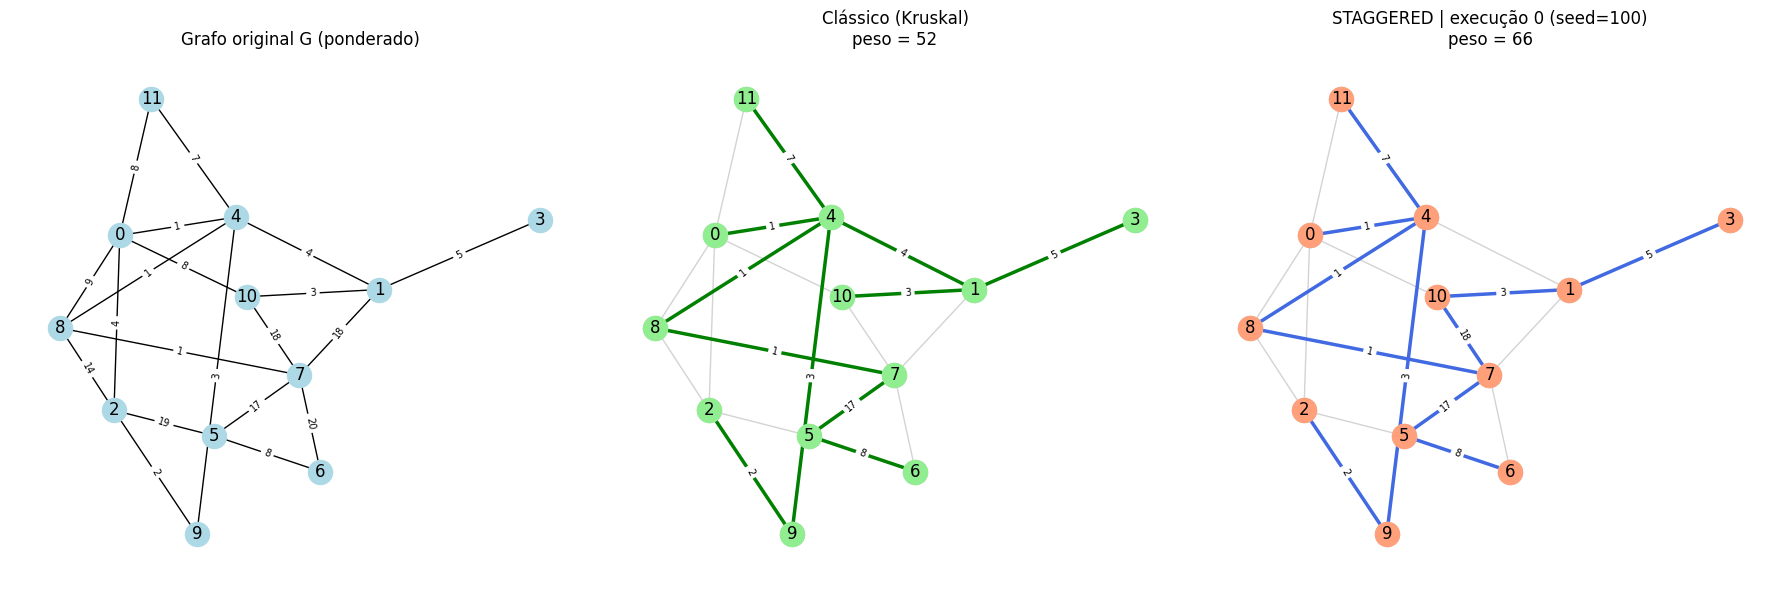

[staggered    ] execução 0 (seed=100) -> peso = 66


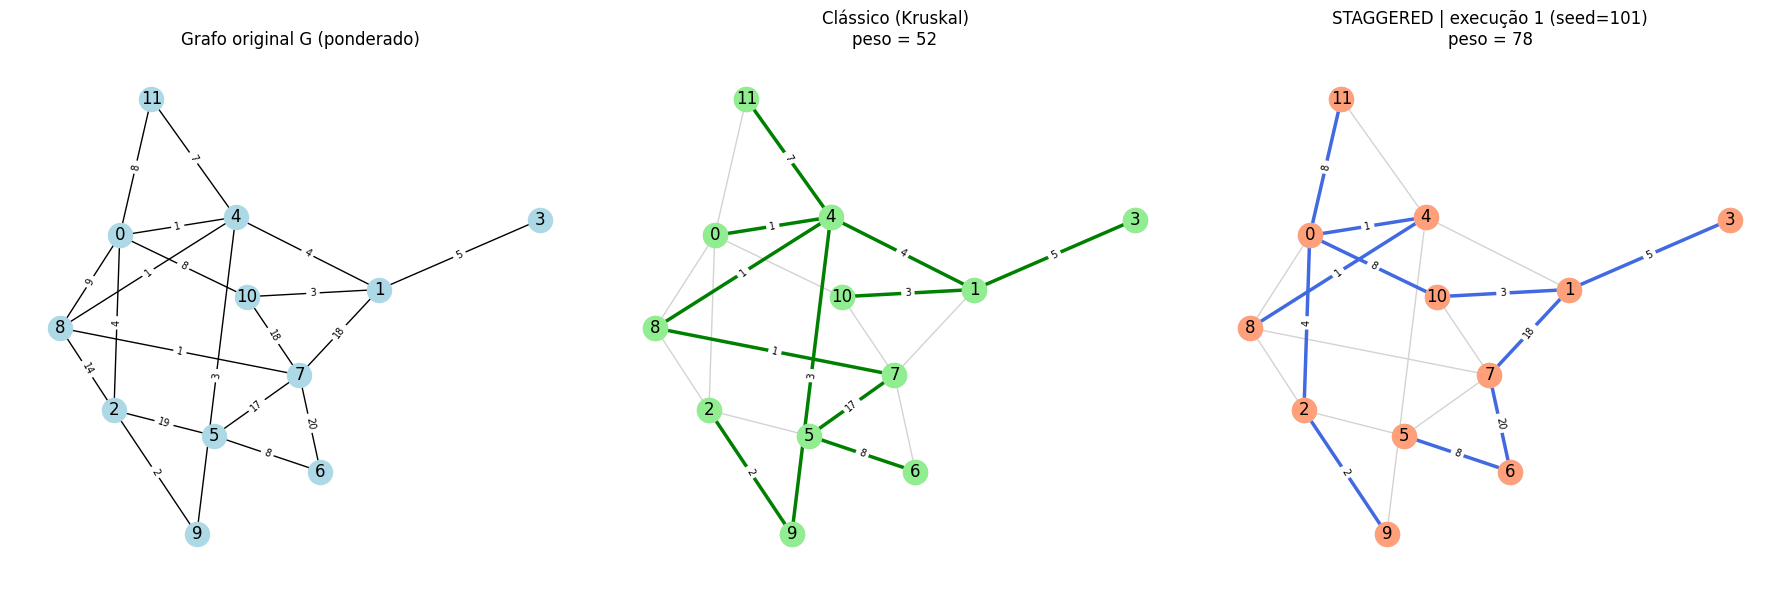

[staggered    ] execução 1 (seed=101) -> peso = 78


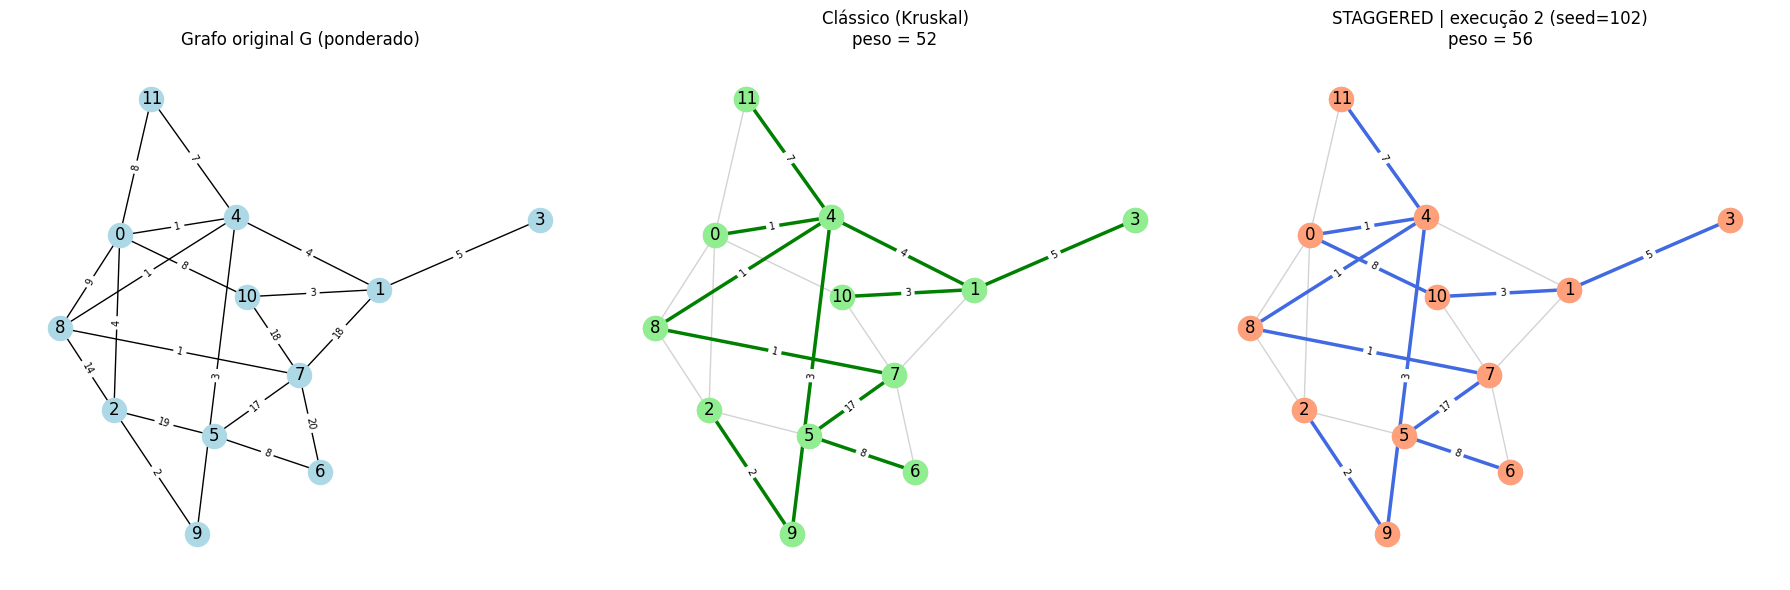

[staggered    ] execução 2 (seed=102) -> peso = 56


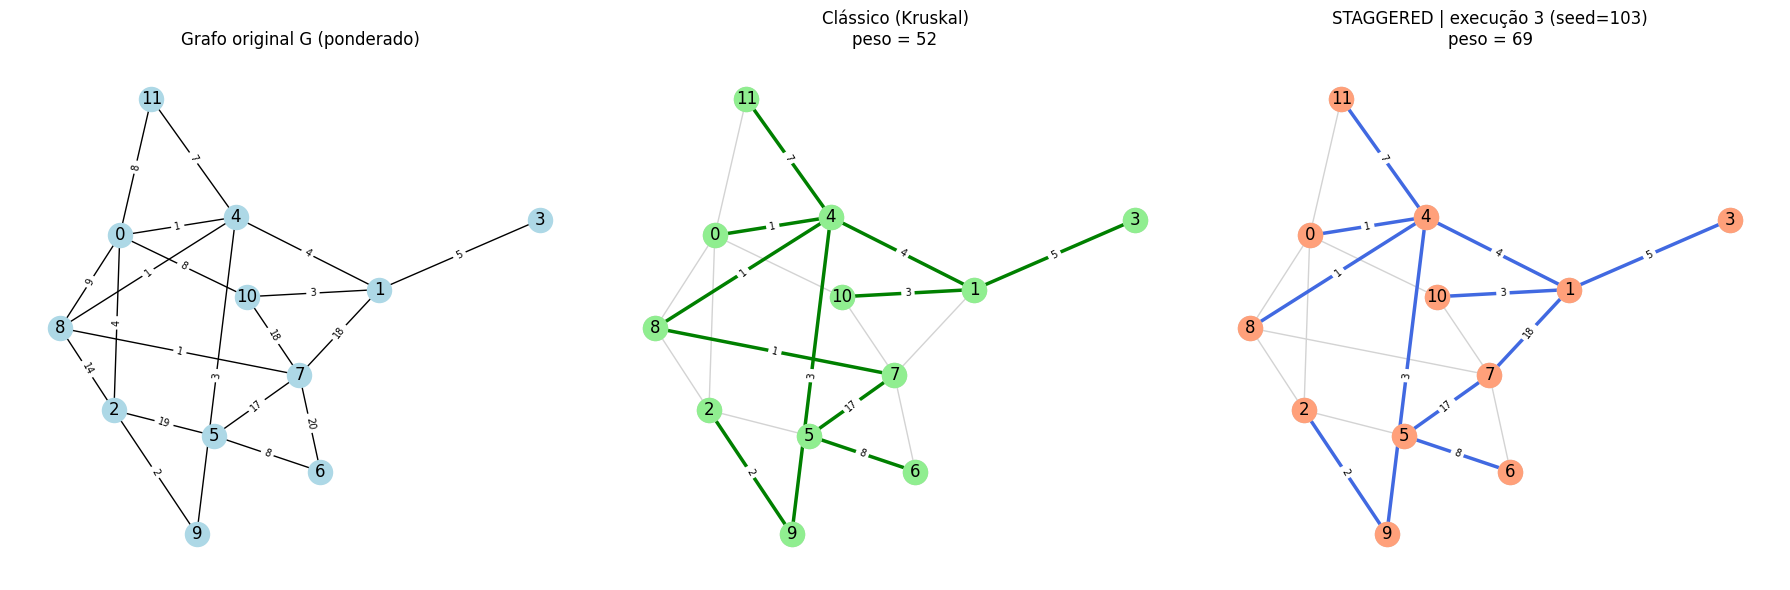

[staggered    ] execução 3 (seed=103) -> peso = 69
  -> média = 67.2 | melhor = 56

MELHOR MÉTODO QUÂNTICO: LACKADAISICAL
  seed usada        : 101
  peso obtido       : 52
  peso ótimo (MST)  : 52
  diferença         : 0 (0.0% acima do ótimo)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

# ===================== Grafo ponderado (fixo p/ comparação justa) =====================
n = 12
G = nx.erdos_renyi_graph(n, 0.25, seed=42)
while not nx.is_connected(G):
    G = nx.erdos_renyi_graph(n, 0.25, seed=random.randint(0, 10000))

rng_w = random.Random(42)
for u, v in G.edges():
    G[u][v]['weight'] = rng_w.randint(1, 20)

NODES = list(G.nodes())
N = len(NODES)
POS = nx.spring_layout(G, seed=42)          # mesmo layout em todos os plots

# ===================== MST exata (Kruskal) =====================
class UnionFind:
    def __init__(self, nodes):
        self.parent = {v: v for v in nodes}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        self.parent[ra] = rb
        return True

def kruskal_tree(G):
    edges = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    uf = UnionFind(G.nodes())
    tree_edges = []
    for u, v, data in edges:
        if uf.union(u, v):
            tree_edges.append((u, v, data['weight']))
        if len(tree_edges) == G.number_of_nodes() - 1:
            break
    T = nx.Graph()
    T.add_nodes_from(G.nodes())
    T.add_weighted_edges_from(tree_edges)
    return T, tree_edges

T_KRUSKAL, KRUSKAL_EDGES = kruskal_tree(G)
MST_OPTIMAL = sum(w for _, _, w in KRUSKAL_EDGES)

# ===================== Espaço de arcos (Hadamard / Grover / Lackadaisical) =====================
def build_arcs(G, self_loops=False):
    arcs = []
    for u, v in G.edges():
        arcs.append((u, v)); arcs.append((v, u))
    if self_loops:
        for v in G.nodes():
            arcs.append((v, v))
    return arcs, {a: i for i, a in enumerate(arcs)}

def grover_block(d):
    J = np.ones((d, d))
    return 2 / d * J - np.eye(d)

def dft_block(d):
    w = np.exp(2j * np.pi / d)
    idx = np.arange(d)
    return np.array([[w ** (a * b) for b in idx] for a in idx]) / np.sqrt(d)

def build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False):
    dim = len(arcs)
    C = np.zeros((dim, dim), dtype=complex)
    for v in G.nodes():
        out_arcs = [(v, u) for u in G.neighbors(v)]
        if self_loops:
            out_arcs.append((v, v))
        d = len(out_arcs)
        if d == 0: continue
        idxs = [arc_index[a] for a in out_arcs]
        Cv = block_fn(d)
        for i, gi in enumerate(idxs):
            for j, gj in enumerate(idxs):
                C[gi, gj] = Cv[i, j]
    return C

def build_shift_arc(arcs, arc_index):
    dim = len(arcs)
    S = np.zeros((dim, dim))
    for (u, v), i in arc_index.items():
        S[arc_index[(v, u)], i] = 1
    return S

def vertex_marginal_arc(psi, arc_index, nodes):
    probs = np.abs(psi) ** 2
    vp = {v: 0.0 for v in nodes}
    for (u, v), i in arc_index.items():
        vp[u] += probs[i]
    return vp

def build_lackadaisical(G):
    arcs, arc_index = build_arcs(G, self_loops=True)
    C = build_coin_arc(G, arcs, arc_index, grover_block, self_loops=True)
    S = build_shift_arc(arcs, arc_index)
    return arcs, arc_index, S @ C

# ===================== Szegedy (dimensão n x n) =====================
def build_szegedy(G):
    A = nx.to_numpy_array(G, nodelist=NODES)
    deg = A.sum(axis=1)
    P = A / deg[:, None]
    dim = N * N
    def idx(x, y): return x * N + y

    psi_vecs = np.zeros((N, dim))
    phi_vecs = np.zeros((N, dim))
    for x in range(N):
        for y in range(N):
            if P[x, y] > 0:
                psi_vecs[x, idx(x, y)] = np.sqrt(P[x, y])
                phi_vecs[y, idx(x, y)] = np.sqrt(P[x, y])

    R_A = 2 * (psi_vecs.T @ psi_vecs) - np.eye(dim)
    R_B = 2 * (phi_vecs.T @ phi_vecs) - np.eye(dim)
    return psi_vecs, R_B @ R_A

def szegedy_marginal(psi):
    probs = np.abs(psi) ** 2
    mat = probs.reshape(N, N)
    col_sum = mat.sum(axis=0)
    return {v: col_sum[i] for i, v in enumerate(NODES)}

# ===================== Staggered (tesselações via matchings) =====================
def build_tessellations(G):
    H = G.copy()
    tess = []
    while H.number_of_edges() > 0:
        M = nx.maximal_matching(H)
        tess.append(list(M))
        H.remove_edges_from(M)
    return tess

def tessellation_unitary(tess, node_index):
    U = np.eye(N, dtype=complex)
    for (u, v) in tess:
        i, j = node_index[u], node_index[v]
        U[i, i] = 0; U[j, j] = 0
        U[i, j] = 1; U[j, i] = 1
    return U

def build_staggered(G):
    node_index = {v: i for i, v in enumerate(NODES)}
    tess = build_tessellations(G)
    U_total = np.eye(N, dtype=complex)
    for t in tess:
        U_total = tessellation_unitary(t, node_index) @ U_total
    return U_total

# ===================== Construção da árvore quântica (retorna arestas) =====================
def quantum_tree_edges(coin_type, start, seed, coin_steps):
    r = random.Random(seed)
    node_index = {v: i for i, v in enumerate(NODES)}

    if coin_type in ("hadamard", "grover"):
        arcs, arc_index = build_arcs(G, self_loops=False)
        block_fn = dft_block if coin_type == "hadamard" else grover_block
        C = build_coin_arc(G, arcs, arc_index, block_fn, self_loops=False)
        S = build_shift_arc(arcs, arc_index)
        U = S @ C
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(len(neigh))
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "lackadaisical":
        arcs, arc_index, U = build_lackadaisical(G)
        psi = np.zeros(len(arcs), dtype=complex)
        neigh = list(G.neighbors(start))
        d1 = len(neigh) + 1
        for u in neigh:
            psi[arc_index[(start, u)]] = 1 / np.sqrt(d1)
        psi[arc_index[(start, start)]] = 1 / np.sqrt(d1)
        step = lambda p: U @ p
        marg = lambda p: vertex_marginal_arc(p, arc_index, NODES)

    elif coin_type == "szegedy":
        psi_vecs, W = build_szegedy(G)
        psi = psi_vecs[node_index[start]].astype(complex)
        step = lambda p: W @ p
        marg = szegedy_marginal

    elif coin_type == "staggered":
        U_total = build_staggered(G)
        psi = np.zeros(N, dtype=complex)
        psi[node_index[start]] = 1.0
        step = lambda p: U_total @ p
        marg = lambda p: {v: np.abs(p[i]) ** 2 for i, v in enumerate(NODES)}

    else:
        raise ValueError(coin_type)

    visited = {start}
    tree_edges = []

    while len(visited) < G.number_of_nodes():
        for _ in range(coin_steps):
            psi = step(psi)

        vp = marg(psi)
        frontier = [v for v in G.nodes() if v not in visited and
                    any(x in visited for x in G.neighbors(v))]
        if not frontier:
            break

        wv = np.array([vp[v] for v in frontier])
        wv = wv / wv.sum() if wv.sum() > 1e-12 else np.ones(len(frontier)) / len(frontier)

        chosen = r.choices(frontier, weights=wv, k=1)[0]
        candidates = [(x, G[chosen][x]['weight']) for x in G.neighbors(chosen) if x in visited]
        parent, wgt = min(candidates, key=lambda t: t[1])

        tree_edges.append((parent, chosen, wgt))
        visited.add(chosen)

    return tree_edges

# ===================== Plot: grafo, clássico (Kruskal) e quantum, lado a lado =====================
def plot_execucao(coin_type, run_idx, seed, quantum_edges, quantum_weight):
    T_q = nx.Graph()
    T_q.add_nodes_from(G.nodes())
    T_q.add_weighted_edges_from(quantum_edges)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    nx.draw(G, POS, ax=axes[0], with_labels=True, node_color="lightblue")
    nx.draw_networkx_edge_labels(G, POS, edge_labels=edge_labels, ax=axes[0], font_size=7)
    axes[0].set_title("Grafo original G (ponderado)")

    nx.draw(G, POS, ax=axes[1], edge_color="lightgray", node_color="lightgray")
    nx.draw(T_KRUSKAL, POS, ax=axes[1], with_labels=True, node_color="lightgreen",
            edge_color="green", width=2.5)
    nx.draw_networkx_edge_labels(T_KRUSKAL, POS, edge_labels=nx.get_edge_attributes(T_KRUSKAL, 'weight'),
                                  ax=axes[1], font_size=7)
    axes[1].set_title(f"Clássico (Kruskal)\npeso = {MST_OPTIMAL}")

    nx.draw(G, POS, ax=axes[2], edge_color="lightgray", node_color="lightgray")
    nx.draw(T_q, POS, ax=axes[2], with_labels=True, node_color="lightsalmon",
            edge_color="royalblue", width=2.5)
    nx.draw_networkx_edge_labels(T_q, POS, edge_labels=nx.get_edge_attributes(T_q, 'weight'),
                                  ax=axes[2], font_size=7)
    axes[2].set_title(f"{coin_type.upper()} | execução {run_idx} (seed={seed})\npeso = {quantum_weight}")

    plt.tight_layout()
    plt.show()

# ===================== Executa cada moeda, cada execução, plotando sempre =====================
def run(coin_type, run_idx, run_seed, run_start=None, coin_steps=2):
    start = run_start if run_start is not None else random.choice(NODES)
    edges = quantum_tree_edges(coin_type, start, run_seed, coin_steps)
    weight = sum(w for _, _, w in edges)
    plot_execucao(coin_type, run_idx, run_seed, edges, weight)
    return weight

COINS = ["hadamard", "grover", "lackadaisical", "szegedy", "staggered"]
N_EXECUCOES = 4

results = {}
print(f"MST ótima (Kruskal) = {MST_OPTIMAL}\n")

for coin in COINS:
    weights = []
    for i in range(N_EXECUCOES):
        w = run(coin, run_idx=i, run_seed=100 + i, coin_steps=2)
        weights.append(w)
        print(f"[{coin:13s}] execução {i} (seed={100+i}) -> peso = {w}")
    results[coin] = weights
    print(f"  -> média = {np.mean(weights):.1f} | melhor = {min(weights)}\n")

# ===================== Melhor método quântico encontrado =====================
best_coin = min(results, key=lambda c: min(results[c]))
best_weight = min(results[best_coin])
best_run_idx = results[best_coin].index(best_weight)
best_seed = 100 + best_run_idx

print("=" * 55)
print(f"MELHOR MÉTODO QUÂNTICO: {best_coin.upper()}")
print(f"  seed usada        : {best_seed}")
print(f"  peso obtido       : {best_weight}")
print(f"  peso ótimo (MST)  : {MST_OPTIMAL}")
print(f"  diferença         : {best_weight - MST_OPTIMAL} "
      f"({100*(best_weight - MST_OPTIMAL)/MST_OPTIMAL:.1f}% acima do ótimo)")
print("=" * 55)